# CNN Image Classification using MNIST

**Student Roll No:** `24BAD047`

## AIM
To design, implement, and evaluate a Convolutional Neural Network (CNN) for image classification using the MNIST handwritten digit dataset.

## Objectives
- Understand the architecture of CNNs.
- Implement a CNN for image classification.
- Train and evaluate the CNN using MNIST.
- Visualize training and validation performance.
- Analyze classification accuracy, confusion matrix, predictions, and errors.


## SOFTWARE REQUIREMENTS
- Python
- TensorFlow/Keras
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib
- Scikit-learn


## PART A: DATASET PREPARATION

MNIST contains 60,000 training images and 10,000 testing images. Each image is a 28×28 grayscale image representing one digit from 0 to 9.

In [1]:
# Student Roll No: YOUR_ROLL_NO

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", x_test.shape)
print("Testing labels :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


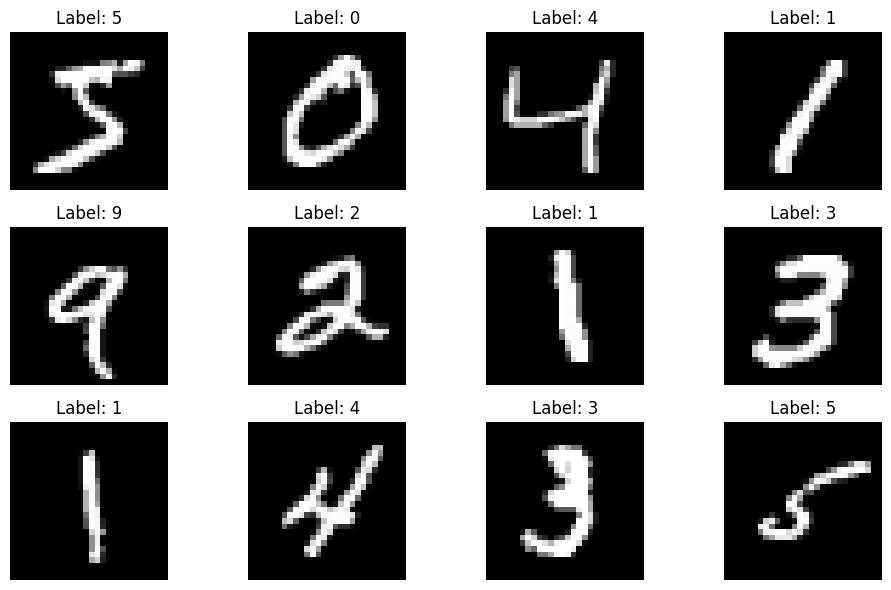

In [3]:
# Display sample images
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add the grayscale channel dimension for CNN input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)
print("Pixel range  :", x_train.min(), "to", x_train.max())

Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)
Pixel range  : 0.0 to 1.0


In [5]:
# Create validation set from the last 5,000 training samples
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training   :", x_train.shape)
print("Validation :", x_val.shape)
print("Testing    :", x_test.shape)

Training   : (55000, 28, 28, 1)
Validation : (5000, 28, 28, 1)
Testing    : (10000, 28, 28, 1)


## PART B: CNN MODEL IMPLEMENTATION

CNN architecture:

`Input → Conv2D → ReLU → MaxPooling → Conv2D → ReLU → MaxPooling → Flatten → Dense → Dropout → Softmax`

In [6]:
# Build CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


### PART C: MODEL TRAINING AND EVALUATION

In [8]:
# Train the CNN
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9132 - loss: 0.2806 - val_accuracy: 0.9842 - val_loss: 0.0591
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9707 - loss: 0.1005 - val_accuracy: 0.9862 - val_loss: 0.0492
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9787 - loss: 0.0713 - val_accuracy: 0.9906 - val_loss: 0.0353
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9821 - loss: 0.0606 - val_accuracy: 0.9924 - val_loss: 0.0302
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.0496 - val_accuracy: 0.9894 - val_loss: 0.0369
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9876 - loss: 0.0414 - val_accuracy: 0.9918 - val_loss: 0.0309
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9891 - loss: 0.0360 - val_accuracy: 0.9926 - val_loss: 0.0362
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9895 - loss: 0.0332 - val_accuracy: 0

In [9]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Testing Loss     : {test_loss:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Testing Loss     : 0.0256
Testing Accuracy : 0.9917 (99.17%)


In [10]:
# Record final training and validation metrics
print(f"Final Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history.history['val_loss'][-1]:.4f}")
print(f"Testing Accuracy          : {test_accuracy:.4f}")

Final Training Accuracy   : 0.9912
Final Validation Accuracy : 0.9916
Final Training Loss       : 0.0269
Final Validation Loss     : 0.0332
Testing Accuracy          : 0.9917


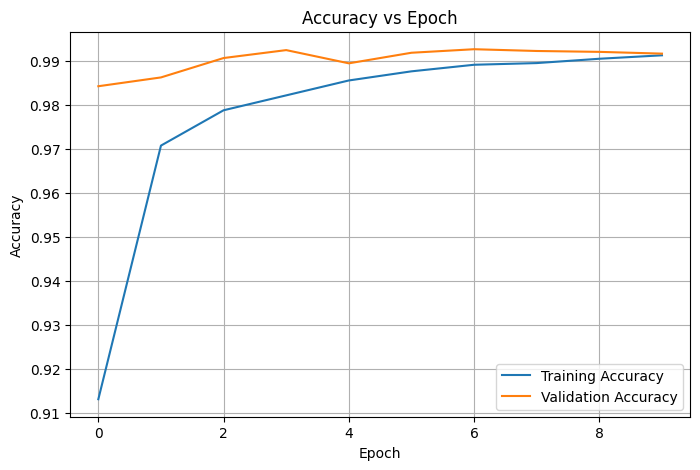

In [11]:
# Plot Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

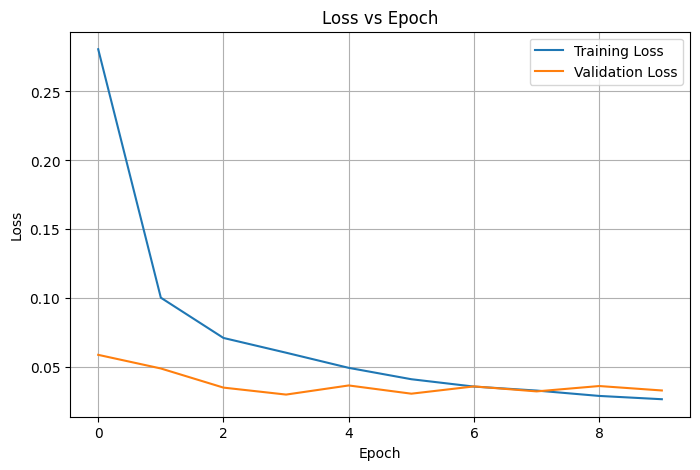

In [12]:
# Plot Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## PART D: PERFORMANCE ANALYSIS

In [13]:
# Generate predictions
predictions = model.predict(x_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = y_test

print("First 20 predicted labels:")
print(predicted_classes[:20])
print("\nFirst 20 actual labels:")
print(actual_classes[:20])

First 20 predicted labels:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]

First 20 actual labels:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


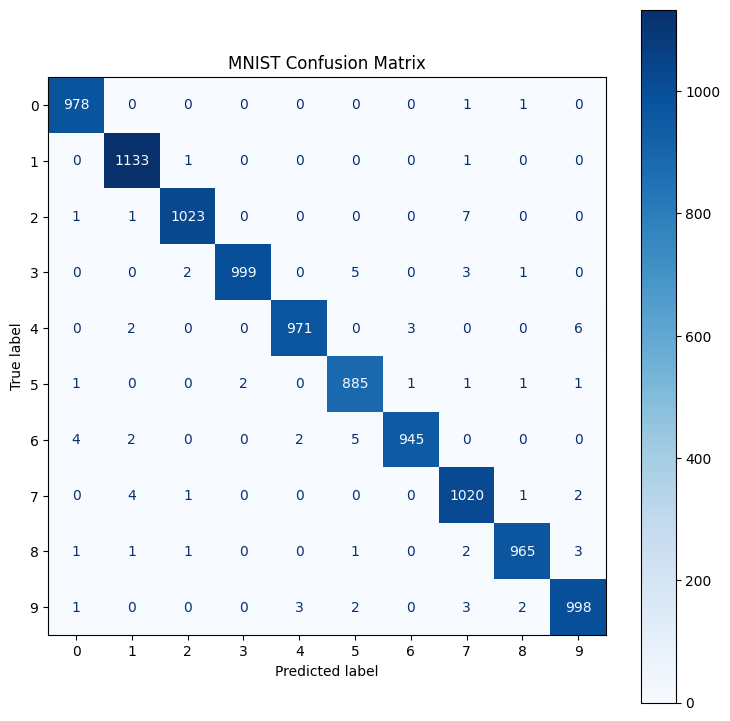

In [14]:
# Confusion Matrix
cm = confusion_matrix(actual_classes, predicted_classes)

fig, ax = plt.subplots(figsize=(9, 9))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('MNIST Confusion Matrix')
plt.show()

In [15]:
# Classification report
print(classification_report(actual_classes, predicted_classes, digits=4))

              precision    recall  f1-score   support

           0     0.9919    0.9980    0.9949       980
           1     0.9913    0.9982    0.9947      1135
           2     0.9951    0.9913    0.9932      1032
           3     0.9980    0.9891    0.9935      1010
           4     0.9949    0.9888    0.9918       982
           5     0.9855    0.9922    0.9888       892
           6     0.9958    0.9864    0.9911       958
           7     0.9827    0.9922    0.9874      1028
           8     0.9938    0.9908    0.9923       974
           9     0.9881    0.9891    0.9886      1009

    accuracy                         0.9917     10000
   macro avg     0.9917    0.9916    0.9916     10000
weighted avg     0.9917    0.9917    0.9917     10000



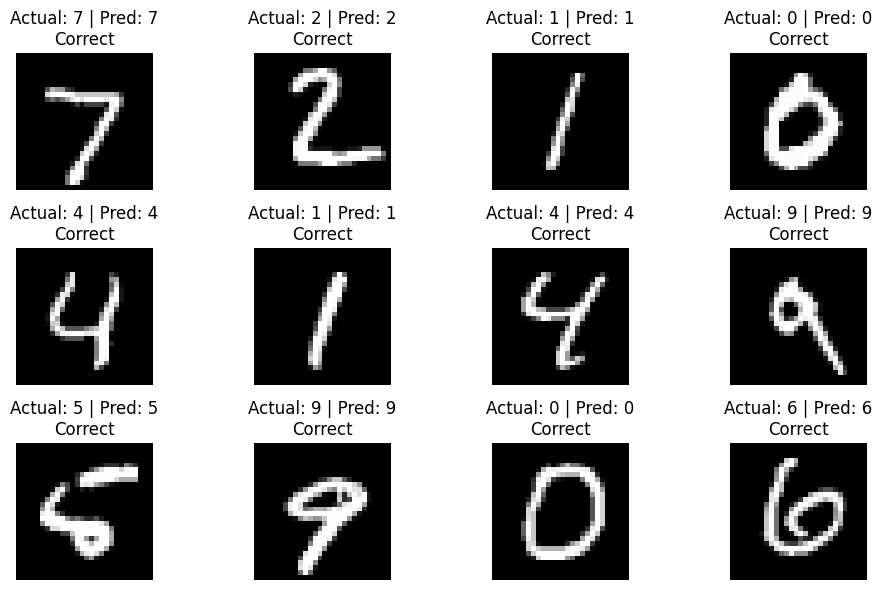

In [16]:
# Display sample predictions
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    actual = actual_classes[i]
    predicted = predicted_classes[i]
    result = 'Correct' if actual == predicted else 'Wrong'

    plt.title(f"Actual: {actual} | Pred: {predicted}\n{result}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Find and display misclassified images
misclassified_indices = np.where(predicted_classes != actual_classes)[0]

print("Number of misclassified images:", len(misclassified_indices))
print("Misclassification rate:", len(misclassified_indices) / len(actual_classes))

Number of misclassified images: 83
Misclassification rate: 0.0083


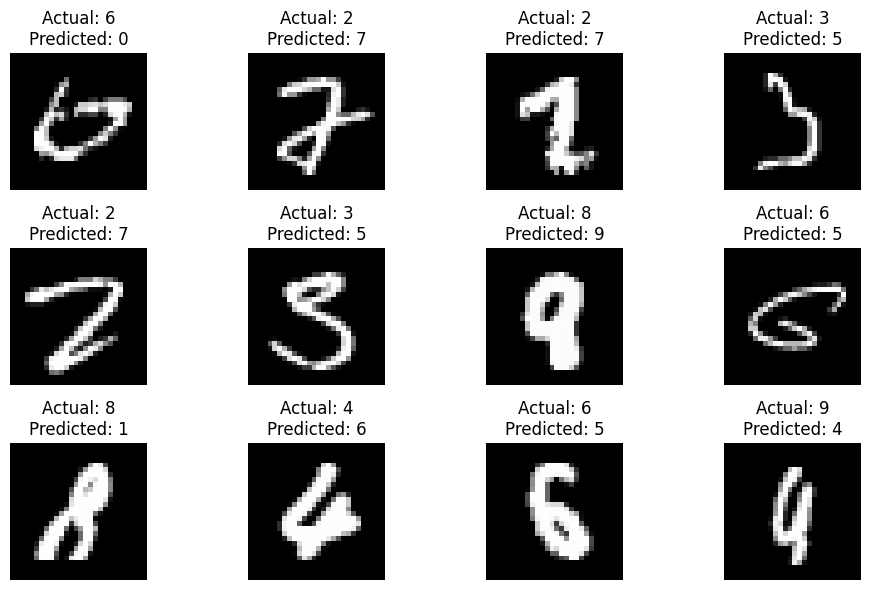

In [18]:
# Display up to 12 misclassified images
plt.figure(figsize=(10, 6))

for i, index in enumerate(misclassified_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.title(
        f"Actual: {actual_classes[index]}\nPredicted: {predicted_classes[index]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
# Count correct and incorrect predictions
correct = np.sum(predicted_classes == actual_classes)
incorrect = np.sum(predicted_classes != actual_classes)

print("Total Test Images   :", len(actual_classes))
print("Correct Predictions :", correct)
print("Incorrect Predictions:", incorrect)
print(f"Test Accuracy       : {correct / len(actual_classes) * 100:.2f}%")

Total Test Images   : 10000
Correct Predictions : 9917
Incorrect Predictions: 83
Test Accuracy       : 99.17%


## PERFORMANCE ANALYSIS

### Strengths of CNN
1. Automatically learns useful image features.
2. Preserves spatial relationships between pixels.
3. Reduces the need for manual feature extraction.
4. Performs very well on image classification tasks.

### Limitations of CNN
1. Training larger CNNs can require significant computational resources.
2. CNNs can overfit without suitable regularization.
3. Performance depends on architecture and hyperparameters.
4. Basic CNNs may struggle with more complex real-world images.
5. CNN predictions are not always easy to interpret.

## RESULT
A Convolutional Neural Network was successfully designed and implemented using the MNIST handwritten digit dataset. The CNN was trained using convolutional layers, ReLU activation, max pooling, fully connected layers, dropout, and a softmax output layer. The model was evaluated using training and validation accuracy/loss, testing accuracy, confusion matrix, sample predictions, classification report, and misclassified images.
